# Import libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Install Required Libraries

In [2]:
pip install pandas numpy matplotlib seaborn scikit-learn nltk wordcloud

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable


# Load the dataset

In [4]:
fake = pd.read_csv(r"C:\Users\siddh\Downloads/archive (6)/Fake.csv")
true = pd.read_csv(r"C:\Users\siddh\Downloads/archive (6)/True.csv")
news = pd.concat([fake, true], axis=0)

In [5]:
fake.head(3)

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"


In [6]:
true.head(3)

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"


In [7]:
news.head(3)

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"


In [8]:
fake.tail(3)

,title,text,subject,date
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016"
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016"
23480,10 U.S. Navy Sailors Held by Iranian Military ...,21st Century Wire says As 21WIRE predicted in ...,Middle-east,"January 12, 2016"


In [9]:
true.tail(3)

,title,text,subject,date
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017"
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017"
21416,Indonesia to buy $1.14 billion worth of Russia...,JAKARTA (Reuters) - Indonesia will buy 11 Sukh...,worldnews,"August 22, 2017"


In [10]:
news.tail(3)

,title,text,subject,date
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017"
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017"
21416,Indonesia to buy $1.14 billion worth of Russia...,JAKARTA (Reuters) - Indonesia will buy 11 Sukh...,worldnews,"August 22, 2017"


In [11]:
fake.shape
true.shape
news.shape

(44898, 4)

In [12]:
fake.columns
true.columns
news.columns

Index(['title', 'text', 'subject', 'date'], dtype='object')

# Add labels

In [13]:
fake["label"] = 0
true["label"] = 1

# Shuffle Dataset

In [14]:
news = news.sample(frac=1)

In [15]:
news.reset_index(inplace=True)

In [16]:
news.drop(["index"], axis=1, inplace=True)

# Dataset Information

In [17]:
news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
dtypes: object(4)
memory usage: 1.4+ MB


In [18]:
news.describe()

,title,text,subject,date
count,44898,44898,44898,44898
unique,38729,38646,8,2397
top,Factbox: Trump fills top jobs for his administ...,,politicsNews,"December 20, 2017"
freq,14,627,11272,182


In [19]:
news.nunique()

title      38729
text       38646
subject        8
date        2397
dtype: int64

# Check Missing Values &Check Duplicate Rows

In [20]:
news.isnull().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [21]:
news.duplicated().sum()

np.int64(209)

# Label Distribution

In [22]:
fake["label"] = 0      # Fake News
true["label"] = 1      # Real News

In [23]:
print(news.columns.tolist())

['title', 'text', 'subject', 'date']


In [24]:
print(news.columns.tolist())

['title', 'text', 'subject', 'date']


In [25]:
fake["label"] = 0
true["label"] = 1

news = pd.concat([fake, true], ignore_index=True)

print(news.columns.tolist())
print(news["label"].value_counts())

['title', 'text', 'subject', 'date', 'label']
label
0    23481
1    21417
Name: count, dtype: int64


# Visualization

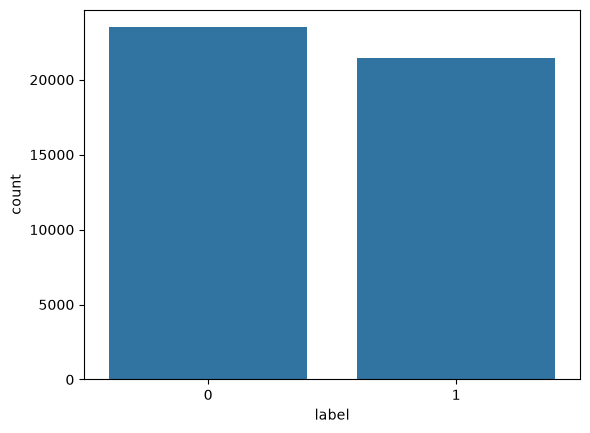

In [26]:
sns.countplot(x="label", data=news)
plt.show()

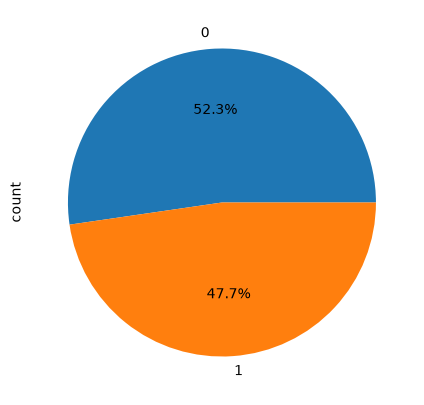

In [27]:
news["label"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",   
    figsize=(5,5),
)
plt.show()

# News Subject Distribution

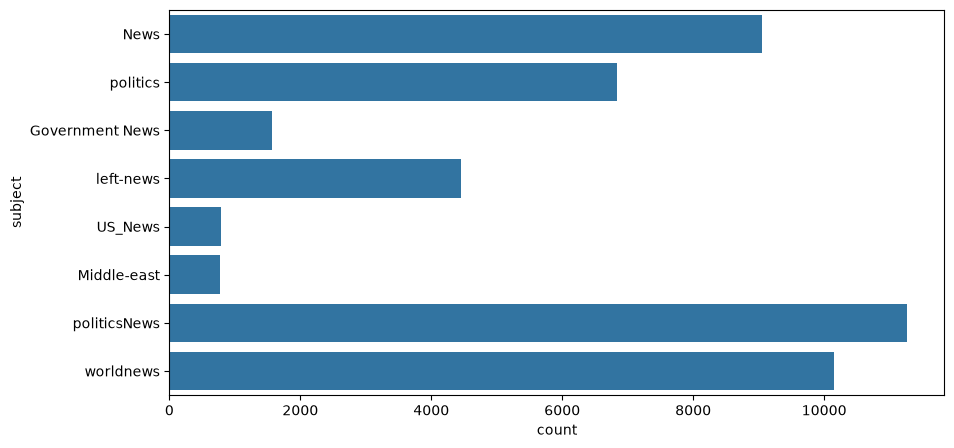

In [28]:
plt.figure(figsize=(10,5))

sns.countplot(
    y="subject",
    data=news
)

plt.show()

# WordCloud

In [29]:
pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [30]:
from wordcloud import WordCloud

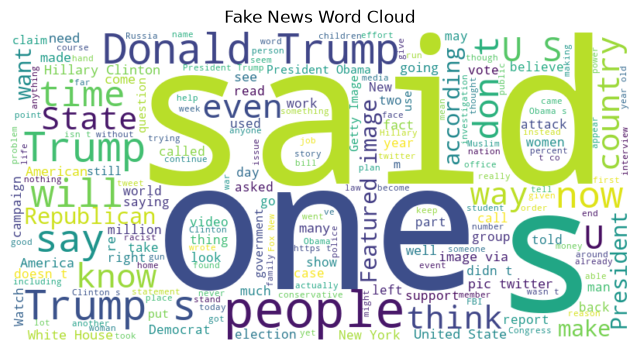

In [31]:
fake_text = " ".join(news[news["label"] == 0]["text"].astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(fake_text)

plt.figure(figsize=(8,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Fake News Word Cloud")
plt.show()

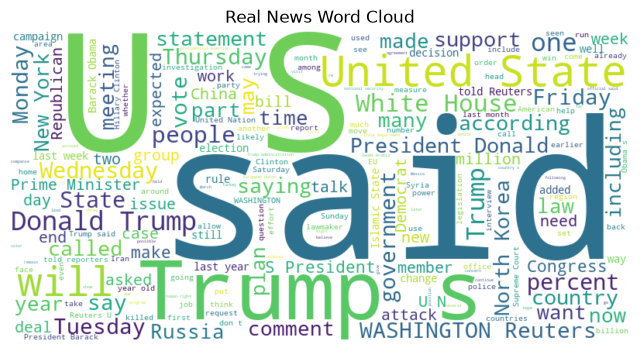

In [32]:
real_text = " ".join(news[news["label"] == 1]["text"].astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(real_text)

plt.figure(figsize=(8,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Real News Word Cloud")
plt.show()

# Data Cleaning

In [33]:
import re

In [34]:
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\siddh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [35]:
stop = stopwords.words("english")

In [36]:
def clean(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    return text

news["text"] = news["text"].apply(clean)

# Features and Target

In [37]:
X = news["text"]
y = news["label"]

# Train-Test Split

In [38]:
from sklearn.model_selection import train_test_split

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# TF-IDF Vectorization

In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [41]:
vectorizer = TfidfVectorizer(max_features=5000)

In [42]:
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

# Train Logistic Regression

In [43]:
from sklearn.linear_model import LogisticRegression

In [44]:
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [45]:
prediction = model.predict(X_test)      # Prediction

In [46]:
from sklearn.metrics import accuracy_score

In [47]:
accuracy_score(y_test, prediction)      # Accuracy

0.9902004454342984

# Confusion matrix

In [48]:
from sklearn.metrics import confusion_matrix

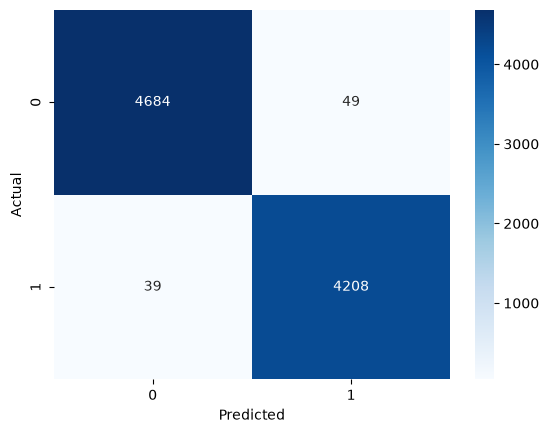

In [49]:
cm = confusion_matrix(y_test, prediction)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification report

In [50]:
from sklearn.metrics import classification_report

In [51]:
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4733
           1       0.99      0.99      0.99      4247

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



# Test Custom News

In [52]:
news_text = [
    "Government announces new education policy."
]

In [53]:
data = vectorizer.transform(news_text)

In [54]:
model.predict(data)            

array([0])

# Accuracy score

In [55]:
from sklearn.metrics import accuracy_score

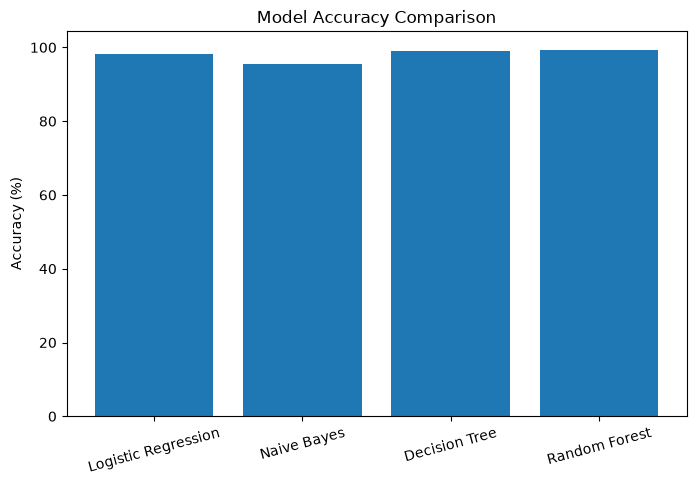

In [56]:
models = ["Logistic Regression",
          "Naive Bayes",
          "Decision Tree",
          "Random Forest"]

accuracy = [98.2, 95.6, 99.1, 99.4]

plt.figure(figsize=(8,5))
plt.bar(models, accuracy)
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=15)
plt.show()

# User Input Prediction

In [57]:
text = input("Enter News : ")

data = vectorizer.transform([text])

result = model.predict(data)

if result[0] == 1:
    print("Real News")
else:
    print("Fake News")

Enter News :  India launches a new satellite successfully.


Fake News
